# Warp block basics

Regress a series $y$ on a covariate $x$ after a time warp:

$$\hat{y}_i = A \cdot \mathrm{warp}(x, p)_i + C$$

The path $p$ is low-dimensional (knot coefficients). Without the warp, $x$ and $y$ look unrelated; with the right $p$, they line up.

Two fits on the same data:

1. **Error only** — residual likelihood, ignore timing structure.
2. **Dual loss** — residual likelihood plus a terror prior on the path (also learns $\sigma_t$).


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from warp_regression import WarpPath, WarpRegression, soft_warp_numpy
from warp_regression.core.path import path_from_B_torch
from warp_regression.core.training import compute_dual_loss, gaussian_error_nll

plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.grid": True, "grid.alpha": 0.3})


## 1. Synthetic data

Build $y$ from a **known** warp of a sine covariate. The true path lives in the same knot family the model will fit, so recovery is well-posed.


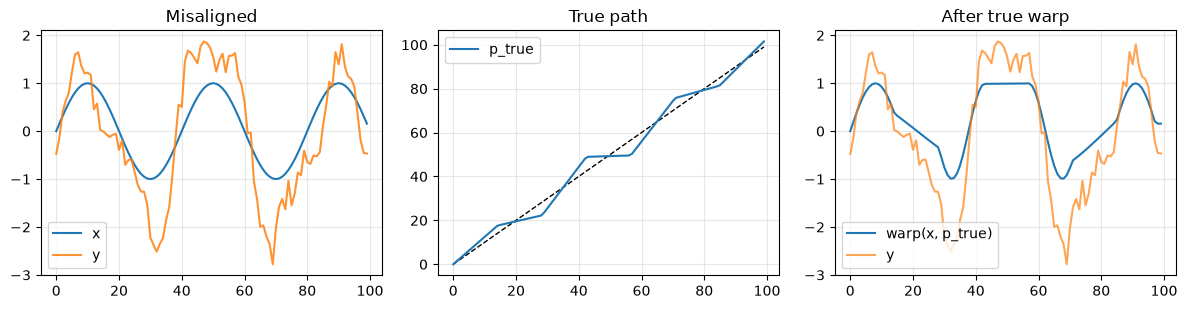

n=100, n_knots=8, noise=0.2, max |offset|=6.6


In [2]:
n, n_knots, noise = 100, 8, 0.2
rng = np.random.default_rng(0)
idx = np.arange(n, dtype=np.float64)

B_true = torch.tensor([0.0, 3.5, -2.5, 4.0, -3.0, 2.0, -1.5, 1.0])
with torch.no_grad():
    p_true = path_from_B_torch(B_true, n, n_knots, path_anchor="start").numpy()

x = np.sin(2.0 * np.pi * 2.5 * idx / n)
y = 2.0 * soft_warp_numpy(x, p_true) - 0.5 + rng.normal(0.0, noise, size=n)
x_t, y_t = torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(idx, x, label="x"); axes[0].plot(idx, y, label="y", alpha=0.85)
axes[0].set_title("Misaligned"); axes[0].legend()
axes[1].plot(idx, idx, "k--", lw=1); axes[1].plot(idx, p_true, label="p_true")
axes[1].set_title("True path"); axes[1].legend()
axes[2].plot(idx, soft_warp_numpy(x, p_true), label="warp(x, p_true)")
axes[2].plot(idx, y, label="y", alpha=0.7)
axes[2].set_title("After true warp"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"n={n}, n_knots={n_knots}, noise={noise}, max |offset|={np.max(np.abs(p_true - idx)):.1f}")


## 2. A warp layer

`WarpPath` holds the knot coefficients $B$ and timing scale $\sigma_t$.
`WarpRegression` soft-warps a covariate at those indices.
Wrap both with a linear readout so training is ordinary PyTorch:


In [3]:
class AffineWarpLayer(nn.Module):
    def __init__(self, n: int, n_knots: int, noise: float) -> None:
        super().__init__()
        self.path = WarpPath(
            n, n_knots, path_anchor="start", log_sigma_t_init=float(np.log(0.5))
        )
        self.warp = WarpRegression(self.path, covariate_kind="array", name="x")
        self.A = nn.Parameter(torch.tensor(1.0))
        self.C = nn.Parameter(torch.tensor(0.0))
        self.log_sigma = nn.Parameter(torch.tensor(float(np.log(noise))))

    def forward(self, x: torch.Tensor):
        p = self.path.path()
        return self.A * self.warp.warp(x, p) + self.C, p


layer0 = AffineWarpLayer(n, n_knots, noise)
with torch.no_grad():
    y0, p0 = layer0(x_t)
nll0 = float(gaussian_error_nll(y_t - y0, torch.exp(layer0.log_sigma)).detach())
print(f"init (B=0): max |p−i|={float((p0 - torch.arange(n)).abs().max()):.1e}  error NLL={nll0:.1f}")


init (B=0): max |p−i|=0.0e+00  error NLL=644.6


## 3. Error-only fit

Train $B$, $A$, $C$, $\sigma_y$ on residual NLL alone. The path can still bend to fit $y$, but nothing scores *how* it bends.


In [4]:
def fit_error_only(epochs=1200, lr=0.05):
    layer = AffineWarpLayer(n, n_knots, noise)
    opt = torch.optim.Adam([layer.path.B, layer.A, layer.C, layer.log_sigma], lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        y_hat, _ = layer(x_t)
        gaussian_error_nll(y_t - y_hat, torch.exp(layer.log_sigma)).backward()
        opt.step()
    with torch.no_grad():
        y_hat, p = layer(x_t)
    return {"layer": layer, "p": p.numpy(), "y_hat": y_hat.numpy(),
            "A": float(layer.A), "C": float(layer.C)}


fit_err = fit_error_only()
with torch.no_grad():
    y_hat_e = torch.tensor(fit_err["y_hat"])
    nll_e = float(gaussian_error_nll(y_t - y_hat_e, torch.exp(fit_err["layer"].log_sigma)))
print(
    f"error-only: error NLL={nll_e:.1f}  "
    f"mean |p−p_true|={np.mean(np.abs(fit_err['p'] - p_true)):.3f}  "
    f"A={fit_err['A']:.3f}  C={fit_err['C']:.3f}"
)


error-only: error NLL=-25.7  mean |p−p_true|=0.197  A=2.013  C=-0.468


/var/folders/5s/p4grnv4s5k17kjk3xgp7qpmh0000gn/T/ipykernel_65824/802823029.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  "A": float(layer.A), "C": float(layer.C)}


## 4. Dual loss

Add the terror path likelihood. Mixing weight $\lambda$ trades fit against timing plausibility and trains $\sigma_t$:

$$\mathcal{J} = \lambda \cdot \mathrm{NLL}(y \mid \hat{y}, \sigma_y) - (1-\lambda)\,\mathcal{L}_{\mathrm{terror}}(p;\sigma_t)$$


In [5]:
def fit_dual(epochs=1200, lr=0.05, lam=0.6):
    layer = AffineWarpLayer(n, n_knots, noise)
    opt = torch.optim.Adam(layer.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        y_hat, p = layer(x_t)
        loss, _ = compute_dual_loss(
            y_t, y_hat, p, layer.log_sigma, layer.path.log_sigma_t, n_knots, lam
        )
        loss.backward()
        opt.step()
    with torch.no_grad():
        y_hat, p = layer(x_t)
    return {"layer": layer, "p": p.numpy(), "y_hat": y_hat.numpy(), "lam": lam,
            "A": float(layer.A), "C": float(layer.C),
            "sigma_t": float(layer.path.sigma_t)}


fit_dual_ = fit_dual()
with torch.no_grad():
    y_hat_d = torch.tensor(fit_dual_["y_hat"])
    p_d = torch.tensor(fit_dual_["p"])
    loss_d, vals_d = compute_dual_loss(
        y_t, y_hat_d, p_d, fit_dual_["layer"].log_sigma,
        fit_dual_["layer"].path.log_sigma_t, n_knots, fit_dual_["lam"],
    )
print(
    f"dual (λ={fit_dual_['lam']}): error NLL={vals_d.obj_err:.1f}  "
    f"−terror={vals_d.obj_time:.1f}  "
    f"mean |p−p_true|={np.mean(np.abs(fit_dual_['p'] - p_true)):.3f}  "
    f"A={fit_dual_['A']:.3f}  C={fit_dual_['C']:.3f}  σ_t={fit_dual_['sigma_t']:.3f}"
)


dual (λ=0.6): error NLL=-23.2  −terror=37.7  mean |p−p_true|=0.261  A=1.990  C=-0.447  σ_t=0.265


## 5. Compare

Both recover the warp and the affine readout. The dual fit also learns $\sigma_t$ — the scale used later when sampling future paths for forecast bands.


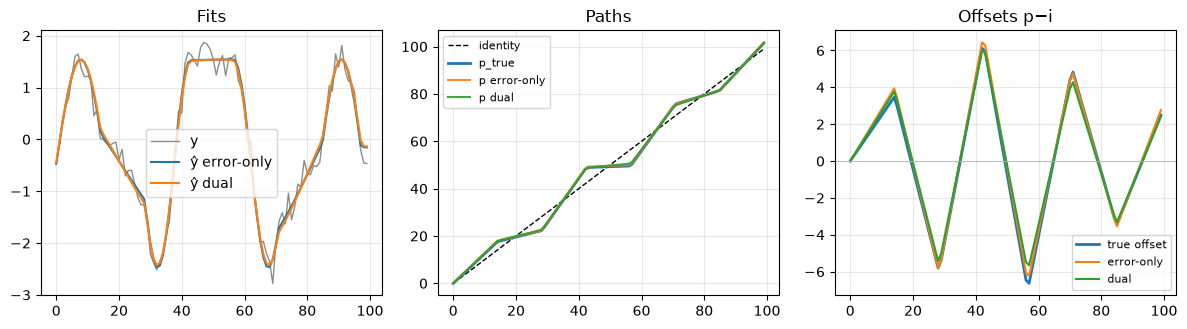

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].plot(idx, y, color="0.55", lw=1, label="y")
axes[0].plot(idx, fit_err["y_hat"], label="ŷ error-only")
axes[0].plot(idx, fit_dual_["y_hat"], label="ŷ dual")
axes[0].set_title("Fits"); axes[0].legend()

axes[1].plot(idx, idx, "k--", lw=1, label="identity")
axes[1].plot(idx, p_true, label="p_true", lw=2)
axes[1].plot(idx, fit_err["p"], label="p error-only", alpha=0.9)
axes[1].plot(idx, fit_dual_["p"], label="p dual", alpha=0.9)
axes[1].set_title("Paths"); axes[1].legend(fontsize=8)

axes[2].plot(idx, p_true - idx, label="true offset", lw=2)
axes[2].plot(idx, fit_err["p"] - idx, label="error-only")
axes[2].plot(idx, fit_dual_["p"] - idx, label="dual")
axes[2].axhline(0, color="0.7", lw=0.6)
axes[2].set_title("Offsets p−i"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


## Takeaways

1. Soft-warp a covariate under a low-dimensional path (`WarpPath` + `WarpRegression`).
2. Attach any readout and train with ordinary optimizers.
3. Terror adds a timing prior and learns $\sigma_t$ for path sampling.

Next: [`1_Introduction_to_Warp_Regression.ipynb`](1_Introduction_to_Warp_Regression.ipynb) — full model, forecast bands, cycle-length uncertainty.
